In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def phi(x,d):
    phi_x= np.array([x**i for i in range(d+1)])
    phi_x= phi_x[...,0].T
    return phi_x


In [3]:
def linear_regression(x,w):
    y_hat= x @ w
    return y_hat

In [4]:
def gradient(x,y,y_hat):
    grads=  2*(x.T @(y_hat - y)) / y.shape[0]
    return grads

In [5]:
def gradient_descent(w,eta,grads):
    w-= eta*grads
    return w

In [6]:
def mse(y,y_hat):
    loss=np.mean((y-y_hat)**2)
    return loss

In [7]:
def mae(y,y_hat):
    loss=np.mean(np.abs(y-y_hat))
    return loss

In [8]:
def r2(y,y_hat):
    return 1-np.sum((y-y_hat)**2) / np.sum((y-y.mean())**2)

Train

In [9]:
d=3
w=np.random.randn(d+1,1)
print(w.shape)

eta=0.1
epochs=2000

(4, 1)


In [10]:
df=pd.read_csv('auto-train-preprocessed.csv')
df.head(5)

,HorsePower,MPG
0,0.038043,0.638298
1,0.646739,0.106383
2,0.157609,0.398936
3,0.239130,0.239362
4,0.728261,0.186170


In [12]:
train_set = np.array(df)

x_train = train_set[:, :-1]
y_train = train_set[:, -1:]


In [13]:
x_train

array([[0.03804347],
       [0.6467391 ],
       [0.15760872],
       [0.23913044],
       [0.7282609 ],
       [0.3206522 ],
       [0.18478262],
       [0.23913044],
       [0.26630437],
       [0.23913044],
       [0.29347825],
       [0.67391306],
       [0.23913044],
       [0.18478262],
       [0.45652175],
       [0.56521744],
       [0.07608697],
       [0.1902174 ],
       [0.27717394],
       [0.5380435 ],
       [0.21195653],
       [0.03804347],
       [0.826087  ],
       [0.45652175],
       [0.4673913 ],
       [0.2554348 ],
       [0.5       ],
       [0.6467391 ],
       [0.5380435 ],
       [0.5923913 ],
       [0.22826087],
       [0.22826087],
       [0.22826087],
       [0.11956522],
       [0.10326088],
       [0.17934784],
       [0.20652175],
       [0.7989131 ],
       [0.6086957 ],
       [0.3206522 ],
       [0.3206522 ],
       [0.15760872],
       [0.11413044],
       [0.07608697],
       [0.56521744],
       [0.40217394],
       [0.45652175],
       [0.179

In [14]:
phi_x_train=phi(x_train,d)
phi_x_train.shape


(352, 4)

In [15]:
error_hist=[]

for epoch in range (epochs):

    y_hat=linear_regression(phi_x_train,w)

    e=mse(y_train,y_hat)
    error_hist.append(e)


    grads= gradient(phi_x_train,y_train,y_hat)


    w=gradient_descent(w,eta,grads)


    if (epoch+1) % 100 == 0:
           print(f'Epoch={epoch}, \t E={e:.4},\t w={w.T[0]}')




Epoch=99, 	 E=0.02303,	 w=[ 0.58276074 -1.02055447  0.77839963  0.07333482]
Epoch=199, 	 E=0.01483,	 w=[ 0.67006629 -1.19445738  0.63876513 -0.02596099]
Epoch=299, 	 E=0.0144,	 w=[ 0.69107603 -1.24515891  0.61468865 -0.03314695]
Epoch=399, 	 E=0.01432,	 w=[ 0.69796796 -1.26904633  0.61462102 -0.02184869]
Epoch=499, 	 E=0.01427,	 w=[ 0.70173241 -1.28645889  0.61931745 -0.00750161]
Epoch=599, 	 E=0.01422,	 w=[ 0.70469207 -1.30172968  0.62474668  0.00669997]
Epoch=699, 	 E=0.01418,	 w=[ 0.70734504 -1.31582025  0.63007762  0.02013419]
Epoch=799, 	 E=0.01414,	 w=[ 0.70980492 -1.32897951  0.63515148  0.03271727]
Epoch=899, 	 E=0.01411,	 w=[ 0.71210381 -1.34130346  0.63994989  0.04447565]
Epoch=999, 	 E=0.01408,	 w=[ 0.71425617 -1.35285312  0.64448312  0.05545617]
Epoch=1099, 	 E=0.01406,	 w=[ 0.71627222 -1.36367953  0.6487665   0.06570729]
Epoch=1199, 	 E=0.01404,	 w=[ 0.71816085 -1.37382922  0.65281563  0.07527537]
Epoch=1299, 	 E=0.01402,	 w=[ 0.71993024 -1.38334546  0.65664535  0.08420403

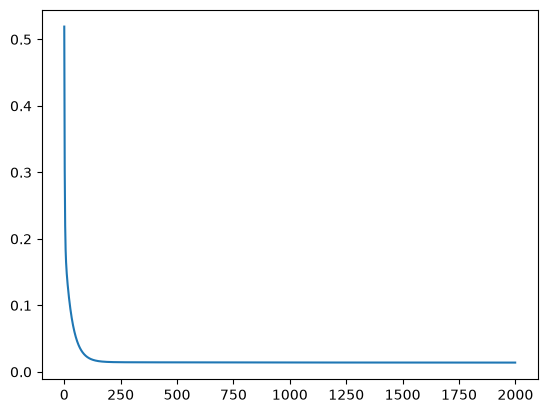

In [16]:
plt.plot(error_hist)

In [17]:
df = pd.read_csv('auto-test-preprocessed.csv')
test_set = np.array(df)

x_test = test_set[:, :-1]
y_test = test_set[:, -1:]

x_test.shape, y_test.shape

((40, 1), (40, 1))

In [18]:
phi_x_test=phi(x_test,d)
phi_x_test.shape

(40, 4)

In [19]:
y_hat_test = linear_regression(phi_x_test, w)
y_hat_test.shape

(40, 1)

In [20]:
mae(y_test, y_hat_test)

np.float64(0.0832861625959364)

In [21]:
r2(y_test,y_hat_test)

np.float64(0.790880733829389)

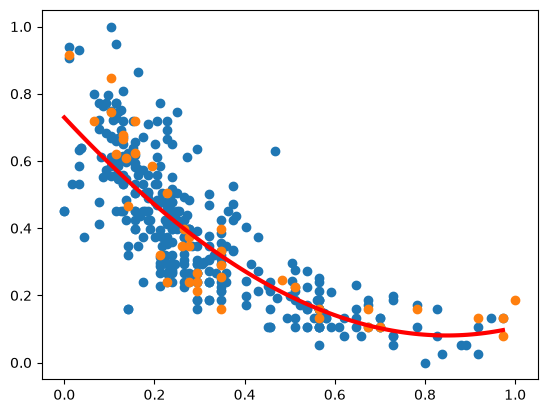

In [22]:
x = np.linspace(x_train.min(), x_train.max(), 100)[:, None]

xp = phi(x,d)
y_hat = linear_regression(xp, w)

plt.scatter(x_train, y_train)
plt.scatter(x_test, y_test)
plt.plot(x, y_hat, 'r', linewidth=3)